<a href="https://colab.research.google.com/github/irghan17/Python-Statistical-Modeling/blob/main/Task%202_Rainfall%20Statistical%20Modeling%20%26%20Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tugas 2 - Teknik Pengolahan Data**

Irghan Santiz Ruqi Antabuana

**Mount Google Drive**

In [ ]:
# Akses ke Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Import Library**



1.   **pandas** (pd): pustaka utama untuk membaca, membersihkan, dan mengolah data tabular (DataFrame).
2.   **numpy** (np): mendukung operasi numerik dan array, sering digunakan bersama pandas.
3. **matplotlib.pyplot** (plt): pustaka dasar untuk membuat grafik/plot di Python.
4. **seaborn** (sns): dibangun di atas matplotlib, menyediakan visualisasi statistik yang lebih menarik dan ringkas (heatmap, boxplot, pairplot).
5. **scipy.stats**: digunakan untuk uji statistik tambahan seperti korelasi Pearson/Spearman dengan p-value.
6. **sns.set_theme**() mengatur gaya visual default agar seluruh grafik pada notebook konsisten dan rapi.

In [ ]:
# Import Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Pengaturan tampilan visualisasi
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


**Memanggil data CSV**
1. **pd.read_csv**() membaca file CSV dan mengubahnya menjadi DataFrame (tabel data).
2. **df.shape** menampilkan jumlah baris dan kolom, sebagai pengecekan cepat apakah data terbaca lengkap (seharusnya 31 baris untuk periode 15 Nov–15 Des 2025)
3. **df.head**(10) menampilkan 10 baris pertama untuk memeriksa struktur data secara visual.

In [ ]:
# Load CSV

path = "/content/drive/MyDrive/00_/Semester 1/Teknik Pengelolaan Data/Collabs/hujan.csv"

df = pd.read_csv(path)
print("Ukuran data:", df.shape)
df.head(10)

Ukuran data: (31, 6)


,Date,CFS,CHIRPS,CPC,ERA5,GPM
0,2025-11-15:12 AM,17.08,5.68,2.02,5.29,1.98
1,2025-11-16:12 AM,16.74,5.91,3.40,7.66,4.04
2,2025-11-17:12 AM,73.20,16.86,24.90,15.19,35.67
3,2025-11-18:12 AM,45.58,15.61,6.33,14.34,8.30
4,2025-11-19:12 AM,40.59,21.18,13.43,19.21,16.14
5,2025-11-20:12 AM,44.10,25.62,21.59,49.90,26.05
6,2025-11-21:12 AM,4.28,3.59,50.59,70.65,47.35
7,2025-11-22:12 AM,15.27,9.04,86.27,74.89,112.00
8,2025-11-23:12 AM,37.37,14.93,65.63,60.86,78.11
9,2025-11-24:12 AM,130.15,53.50,86.45,68.11,112.45


**Merapikan Nama Kolom dan Struktur Data**

Nama kolom hasil unduhan Climate Engine biasanya sangat panjang, misalnya "(mm) Precipitation (CFSR) at Polygon 1, 2025-11-15 to 2025-12-15". Agar analisis lebih mudah, kolom tersebut perlu disederhanakan menjadi nama singkat.
1. df.columns.tolist() menampilkan daftar nama kolom saat ini, berguna untuk memastikan penamaan sudah sesuai sebelum melanjutkan ke tahap berikutnya.
2. df.info() menampilkan ringkasan tipe data setiap kolom (numerik/object) serta jumlah nilai yang tidak kosong (non-null), penting untuk mendeteksi masalah data di awal.


In [ ]:
# Merapikan Struktur Data

# Jika menggunakan Skenario A (1 file gabungan), rename manual sesuai urutan kolom:
# df.columns = ["Tanggal", "CHIRPS", "CFSR", "ERA5", "GPM", "CPC_CMORPH"]

# Jika kolom tanggal masih berupa kolom biasa (bukan index), jadikan index:
df = df.set_index("Date")

# Melihat nama kolom & tipe data saat ini
print(df.columns.tolist())
df.info()


['CFS', 'CHIRPS', 'CPC', 'ERA5', 'GPM']
<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 2025-11-15:12 AM to 2025-12-15:12 AM
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CFS     31 non-null     float64
 1   CHIRPS  31 non-null     float64
 2   CPC     31 non-null     float64
 3   ERA5    31 non-null     float64
 4   GPM     31 non-null     float64
dtypes: float64(5)
memory usage: 1.5+ KB


**Konversi Format Tanggal**

Format tanggal asli dari Climate Engine (contoh: "2025-11-15:12 AM") mengandung tanda ":12 AM" yang sebenarnya adalah artefak jam (jam 00:00, ditulis sebagai 12 AM). Format ini perlu dikonversi menjadi tipe datetime standar.

1. str.replace(":12 AM", "") menghapus akhiran jam yang tidak diperlukan dari string tanggal.
2. pd.to_datetime() mengonversi teks tanggal menjadi objek datetime, sehingga Python dapat mengenalinya sebagai deret waktu (time series), bukan sekadar teks.
3. sort_index() memastikan data terurut secara kronologis dari tanggal paling awal ke paling akhir.

In [ ]:
# Konversi Format Tanggal

# Jika tanggal masih berupa index string seperti "2025-11-15:12 AM"
df.index = df.index.astype(str).str.replace(":12 AM", "", regex=False)
df.index = pd.to_datetime(df.index, format="%Y-%m-%d")
df = df.sort_index()

print(df.index.min(), "sampai", df.index.max())
print("Jumlah hari:", len(df))


2025-11-15 00:00:00 sampai 2025-12-15 00:00:00
Jumlah hari: 31


**Memastika tipe data Numerik**

1. pd.to_numeric(..., errors="coerce") memaksa setiap nilai menjadi angka; jika ada nilai yang tidak bisa dikonversi (misalnya teks atau simbol), nilai tersebut akan diubah menjadi NaN (missing) alih-alih menyebabkan error.
2. df.describe() menampilkan ringkasan statistik awal (jumlah data, rata-rata, standar deviasi, minimum, kuartil, maksimum) sebagai pengecekan cepat.


In [ ]:
# Kolom Numerik

kolom_data = df.columns.tolist()   # semua kolom dataset presipitasi

for k in kolom_data:
    df[k] = pd.to_numeric(df[k], errors="coerce")

df[kolom_data].describe()


,CFS,CHIRPS,CPC,ERA5,GPM
count,31.00,31.00,31.00,31.00,31.00
mean,43.64,15.06,31.99,26.57,34.78
std,57.02,22.86,55.92,41.45,64.19
min,0.24,0.00,0.01,0.38,0.01
25%,9.45,2.16,1.47,3.32,1.14
50%,28.35,6.25,6.33,8.50,8.30
75%,44.84,16.23,37.74,24.76,38.34
max,266.84,102.20,218.37,177.20,316.70


**Penanganan Missing Values**

1. isna().sum() menghitung berapa banyak nilai kosong pada tiap kolom dataset — penting untuk menilai kualitas data sebelum memutuskan strategi penanganan.
2. dropna() akan menghapus baris (tanggal) yang memiliki nilai kosong pada minimal satu dataset. Cocok digunakan bila jumlah missing value relatif sedikit.
3. Sebagai alternatif, interpolate(method="time") mengisi nilai kosong berdasarkan pola antar-tanggal di sekitarnya (cocok untuk deret waktu, tetapi gunakan dengan hati-hati karena bersifat estimasi).


In [ ]:
# Cek data kosong
print(df[kolom_data].isna().sum())

CFS       0
CHIRPS    0
CPC       0
ERA5      0
GPM       0
dtype: int64


In [ ]:
# Cek jumlah missing value per kolom
print(df[kolom_data].isna().sum())

# Opsi 1: hapus baris yang memiliki missing value pada salah satu dataset
df_clean = df.dropna(subset=kolom_data)

# Opsi 2 (alternatif): isi missing value dengan interpolasi linear berbasis waktu
# df_clean = df.copy()
# df_clean[kolom_data] = df_clean[kolom_data].interpolate(method="time")

print("Jumlah baris setelah pembersihan:", len(df_clean))


CFS       0
CHIRPS    0
CPC       0
ERA5      0
GPM       0
dtype: int64
Jumlah baris setelah pembersihan: 31


**Statistik Desktiptif**

Sebelum melakukan visualisasi lanjutan, penting untuk memahami karakteristik dasar dari setiap dataset melalui ukuran pemusatan (rata-rata, median) dan ukuran penyebaran (standar deviasi, rentang nilai) data

1. .agg([...]) menghitung beberapa statistik sekaligus untuk setiap kolom: mean (rata-rata harian), median (nilai tengah), std (standar deviasi/variabilitas), min dan max (nilai ekstrem), serta sum (total akumulasi curah hujan selama periode 15 Nov–15 Des 2025).
2. .T (transpose) membalik baris menjadi kolom agar tabel lebih mudah dibaca, dengan nama dataset sebagai baris.
3. Tabel ini memungkinkan perbandingan cepat: misalnya dataset mana yang mencatat total curah hujan tertinggi, atau dataset mana yang memiliki variabilitas (std) paling besar antar hari.


In [ ]:
#Statistik Deskriptif

ringkasan = df_clean[kolom_data].agg(['mean', 'median', 'std', 'min', 'max', 'sum']).T
ringkasan.columns = ['Rata-rata', 'Median', 'Std Dev', 'Minimum', 'Maksimum', 'Total (mm)']
ringkasan = ringkasan.round(2)
ringkasan

,Rata-rata,Median,Std Dev,Minimum,Maksimum,Total (mm)
CFS,43.64,28.35,57.02,0.24,266.84,"1,352.77"
CHIRPS,15.06,6.25,22.86,0.00,102.20,466.89
CPC,31.99,6.33,55.92,0.01,218.37,991.64
ERA5,26.57,8.50,41.45,0.38,177.20,823.64
GPM,34.78,8.30,64.19,0.01,316.70,"1,078.19"


**Hari dengan curah Hujan tertinggi**

In [ ]:
#Identifikasi Hari dengan curah Hujan tertinggi

for k in kolom_data:
    tgl_max = df_clean[k].idxmax()
    nilai_max = df_clean[k].max()
    print(f"{k:12s} -> curah hujan tertinggi {nilai_max:.2f} mm pada {tgl_max.date()}")


CFS          -> curah hujan tertinggi 266.84 mm pada 2025-11-26
CHIRPS       -> curah hujan tertinggi 102.20 mm pada 2025-11-26
CPC          -> curah hujan tertinggi 218.37 mm pada 2025-11-25
ERA5         -> curah hujan tertinggi 177.20 mm pada 2025-11-26
GPM          -> curah hujan tertinggi 316.70 mm pada 2025-11-25


**Visualisasi Time Series (Perbandingan Antar Waktu)**

Plot deret waktu (time series) membantu melihat pola naik-turun curah hujan harian dari kelima dataset secara bersamaan sepanjang periode 15 November – 15 Desember 2025

1. Perulangan for k in kolom_data menggambar satu garis (line) untuk setiap dataset pada grafik yang sama, sehingga pola antar produk dapat dibandingkan langsung secara visual.
2. bbox_to_anchor pada legend digunakan agar keterangan (legenda) tidak menutupi grafik, ditempatkan di luar area plot.
3. plt.savefig() menyimpan grafik sebagai file gambar (.png) ke penyimpanan sesi Colab, yang nantinya dapat diunduh atau dimasukkan ke laporan.


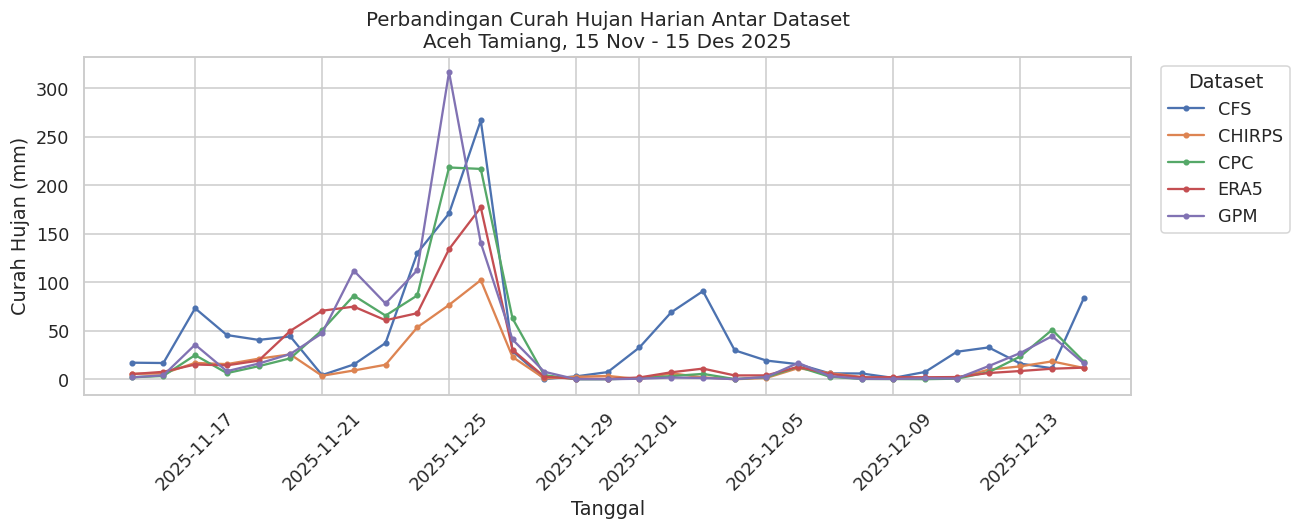

In [ ]:
#Visualisasi Time Series

plt.figure(figsize=(12, 5))
for k in kolom_data:
    plt.plot(df_clean.index, df_clean[k], marker='o', markersize=3, label=k, linewidth=1.5)

plt.title("Perbandingan Curah Hujan Harian Antar Dataset\nAceh Tamiang, 15 Nov - 15 Des 2025", fontsize=13)
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("timeseries_perbandingan.png", dpi=150, bbox_inches='tight')
plt.show()

**Correlation Heatmap (Peta Korelasi Antar Dataset)**

Correlation heatmap digunakan untuk mengukur seberapa kuat dan searah hubungan (korelasi) antara satu produk data curah hujan dengan produk lainnya. Nilai korelasi berkisar antara -1 hingga +1: semakin mendekati +1 berarti kedua dataset memiliki pola yang semakin mirip (korelasi positif kuat), mendekati 0 berarti hubungan lemah/tidak ada pola, dan mendekati -1 berarti berlawanan arah.

1. df_clean[kolom_data].corr(method='pearson') menghitung matriks korelasi Pearson antar semua pasangan kolom dataset. Korelasi Pearson mengukur hubungan linear antar dua variabel numerik.
2. sns.heatmap() memvisualisasikan matriks korelasi sebagai peta warna; annot=True menampilkan nilai angka korelasi langsung pada setiap sel.
3. cmap="RdYlBu_r" adalah skema warna (merah-kuning-biru terbalik) yang umum digunakan agar korelasi tinggi (merah) dan rendah (biru) mudah dibedakan secara visual.
4. vmin=-1, vmax=1 mengunci skala warna agar konsisten dengan rentang teoretis koefisien korelasi.


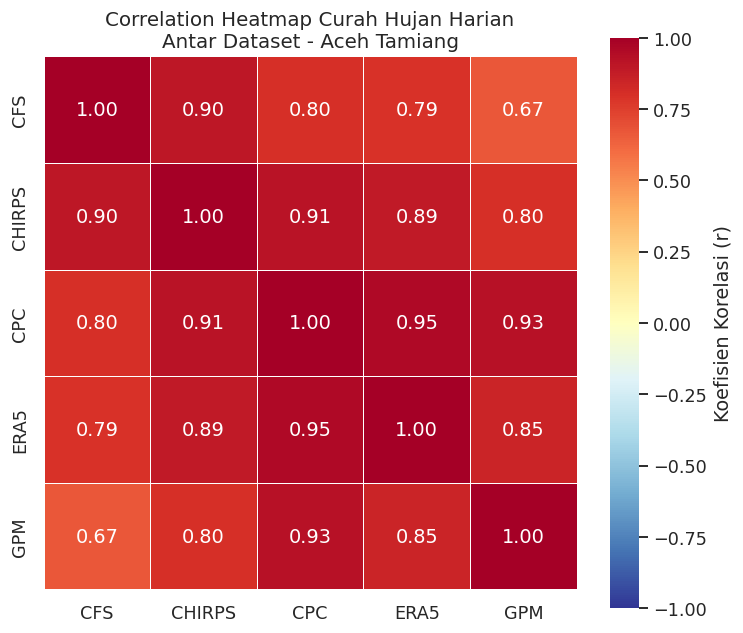

In [ ]:
#Korelasi Heatmap

corr_matrix = df_clean[kolom_data].corr(method='pearson')

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="RdYlBu_r",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Koefisien Korelasi (r)"}
)
plt.title("Correlation Heatmap Curah Hujan Harian\nAntar Dataset - Aceh Tamiang", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


**Boxplot Perbandingan Distribusi Antar Dataset**

Boxplot (diagram kotak-garis) digunakan untuk membandingkan sebaran (distribusi) nilai curah hujan harian dari kelima dataset secara berdampingan. Boxplot menampilkan median, kuartil 1 dan 3 (rentang interkuartil/IQR), serta nilai-nilai pencilan (outlier) pada masing-masing dataset.

1. .melt() mengubah data dari format lebar (setiap dataset sebagai kolom terpisah) menjadi format panjang (long format) dengan dua kolom: nama dataset dan nilai curah hujan. Format ini diperlukan agar seaborn dapat mengelompokkan boxplot berdasarkan kategori dataset.
2. sns.boxplot() menggambar kotak yang merepresentasikan kuartil 1 (Q1) hingga kuartil 3 (Q3), garis tengah sebagai median, dan titik-titik di luar "whisker" sebagai outlier (nilai curah hujan ekstrem).
3. showmeans=True menambahkan penanda berbentuk wajik (diamond) yang menunjukkan nilai rata-rata, sehingga dapat dibandingkan langsung dengan median.
4. sns.stripplot() ditambahkan sebagai lapisan tambahan untuk menampilkan setiap titik data harian secara individual di atas boxplot, memberikan gambaran sebaran data yang lebih detail (opsional, dapat dihapus jika grafik terlalu ramai).

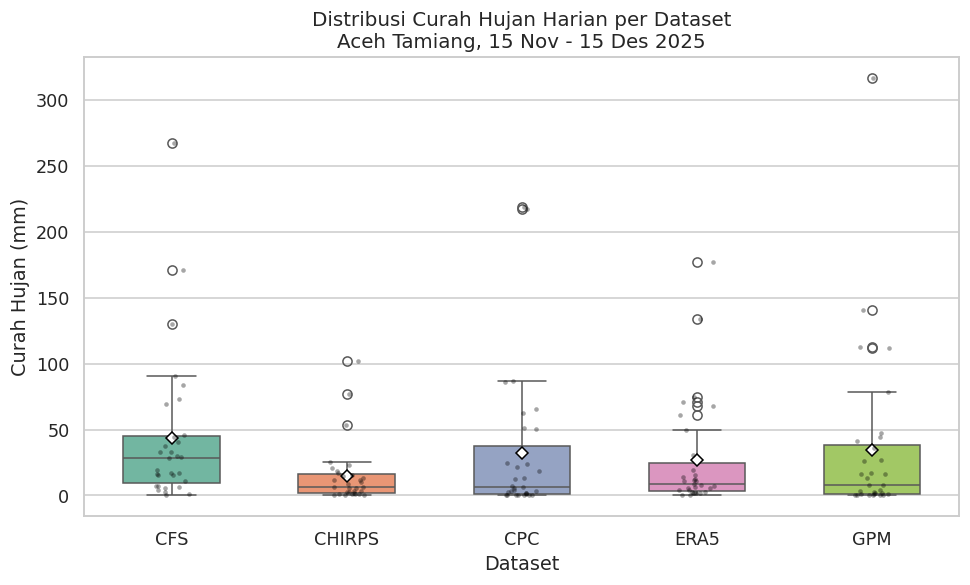

In [ ]:
#Boxplot

df_long = df_clean[kolom_data].melt(var_name="Dataset", value_name="Curah_Hujan_mm")

plt.figure(figsize=(9, 5.5))
sns.boxplot(
    data=df_long, x="Dataset", y="Curah_Hujan_mm",
    hue="Dataset", palette="Set2", legend=False,
    width=0.55, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6}
)
sns.stripplot(
    data=df_long, x="Dataset", y="Curah_Hujan_mm",
    color="black", alpha=0.35, size=3, jitter=True
)
plt.title("Distribusi Curah Hujan Harian per Dataset\nAceh Tamiang, 15 Nov - 15 Des 2025", fontsize=13)
plt.xlabel("Dataset")
plt.ylabel("Curah Hujan (mm)")
plt.tight_layout()
plt.savefig("boxplot_perbandingan.png", dpi=150, bbox_inches='tight')
plt.show()

**Scatter Plot & Pairplot **

Scatter plot digunakan untuk melihat kesesuaian (agreement) antara dua dataset secara langsung, titik per titik berdasarkan tanggal yang sama. Jika titik-titik cenderung membentuk garis lurus diagonal, berarti kedua dataset memiliki kesesuaian yang baik.

1. sns.regplot() menggambar titik-titik data (scatter) sekaligus garis regresi linear terbaik (best-fit line) berwarna merah, yang menunjukkan arah tren hubungan antara dua dataset.
2. Garis putus-putus abu-abu (garis 1:1) merepresentasikan kondisi ideal di mana kedua dataset mencatat nilai yang identik persis. Semakin dekat titik-titik ke garis ini, semakin tinggi kesesuaian kedua produk data.
3. stats.pearsonr() menghitung koefisien korelasi Pearson (r) beserta p-value, yang menunjukkan apakah korelasi tersebut signifikan secara statistik (umumnya signifikan jika p-value < 0.05).


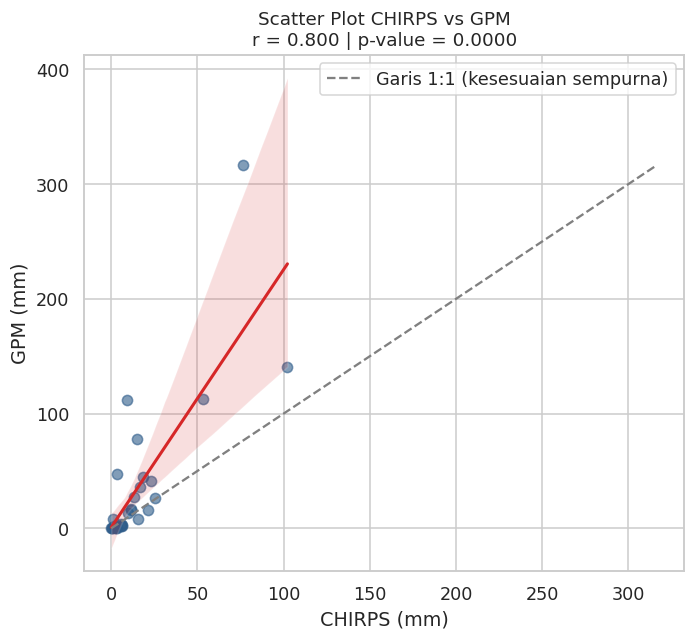

In [ ]:
#Scatter Plot
x_data, y_data = "CHIRPS", "GPM"   # ganti sesuai pasangan dataset yang ingin dibandingkan

plt.figure(figsize=(6.5, 6))
sns.regplot(
    data=df_clean, x=x_data, y=y_data,
    scatter_kws={"alpha": 0.6, "s": 45, "color": "#2E5C8A"},
    line_kws={"color": "#D62728", "linewidth": 2}
)
nilai_maks = max(df_clean[x_data].max(), df_clean[y_data].max())
plt.plot([0, nilai_maks], [0, nilai_maks], linestyle="--", color="grey", label="Garis 1:1 (kesesuaian sempurna)")

r, p_value = stats.pearsonr(df_clean[x_data], df_clean[y_data])
plt.title(f"Scatter Plot {x_data} vs {y_data}\nr = {r:.3f} | p-value = {p_value:.4f}", fontsize=12)
plt.xlabel(f"{x_data} (mm)")
plt.ylabel(f"{y_data} (mm)")
plt.legend()
plt.tight_layout()
plt.savefig(f"scatter_{x_data}_vs_{y_data}.png", dpi=150, bbox_inches='tight')
plt.show()


<Axes: xlabel='CHIRPS', ylabel='GPM'>

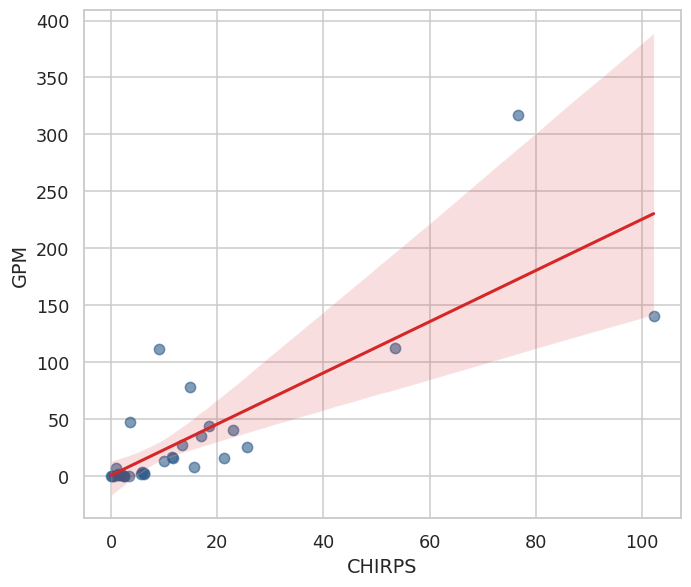

In [ ]:
# Scatter Plot

x_data, y_data = "CHIRPS", "GPM" #sesuai kolom mana data yang dibandingin

plt.figure(figsize=(7,6))
sns.regplot(
    data=df_clean, x=x_data, y=y_data,
    scatter_kws={"alpha":0.6, "s":45, "color":"#2E5C8A"},
    line_kws={"color":"#D62728", "linewidth":2},
 )


**Pairplot**

1. sns.pairplot() secara otomatis membuat matriks scatter plot untuk semua kombinasi pasangan kolom (5 dataset menghasilkan 10 kombinasi pasangan).
2. kind="reg" menambahkan garis regresi linear pada setiap scatter plot, sama seperti regplot sebelumnya.
3. diag_kind="kde" menampilkan kurva kepadatan (density plot) pada diagonal matriks, menggambarkan distribusi masing-masing dataset secara individual.
4. corner=True menampilkan hanya separuh matriks (segitiga bawah) agar tidak terjadi duplikasi pasangan yang sama, sehingga tampilan lebih ringkas.


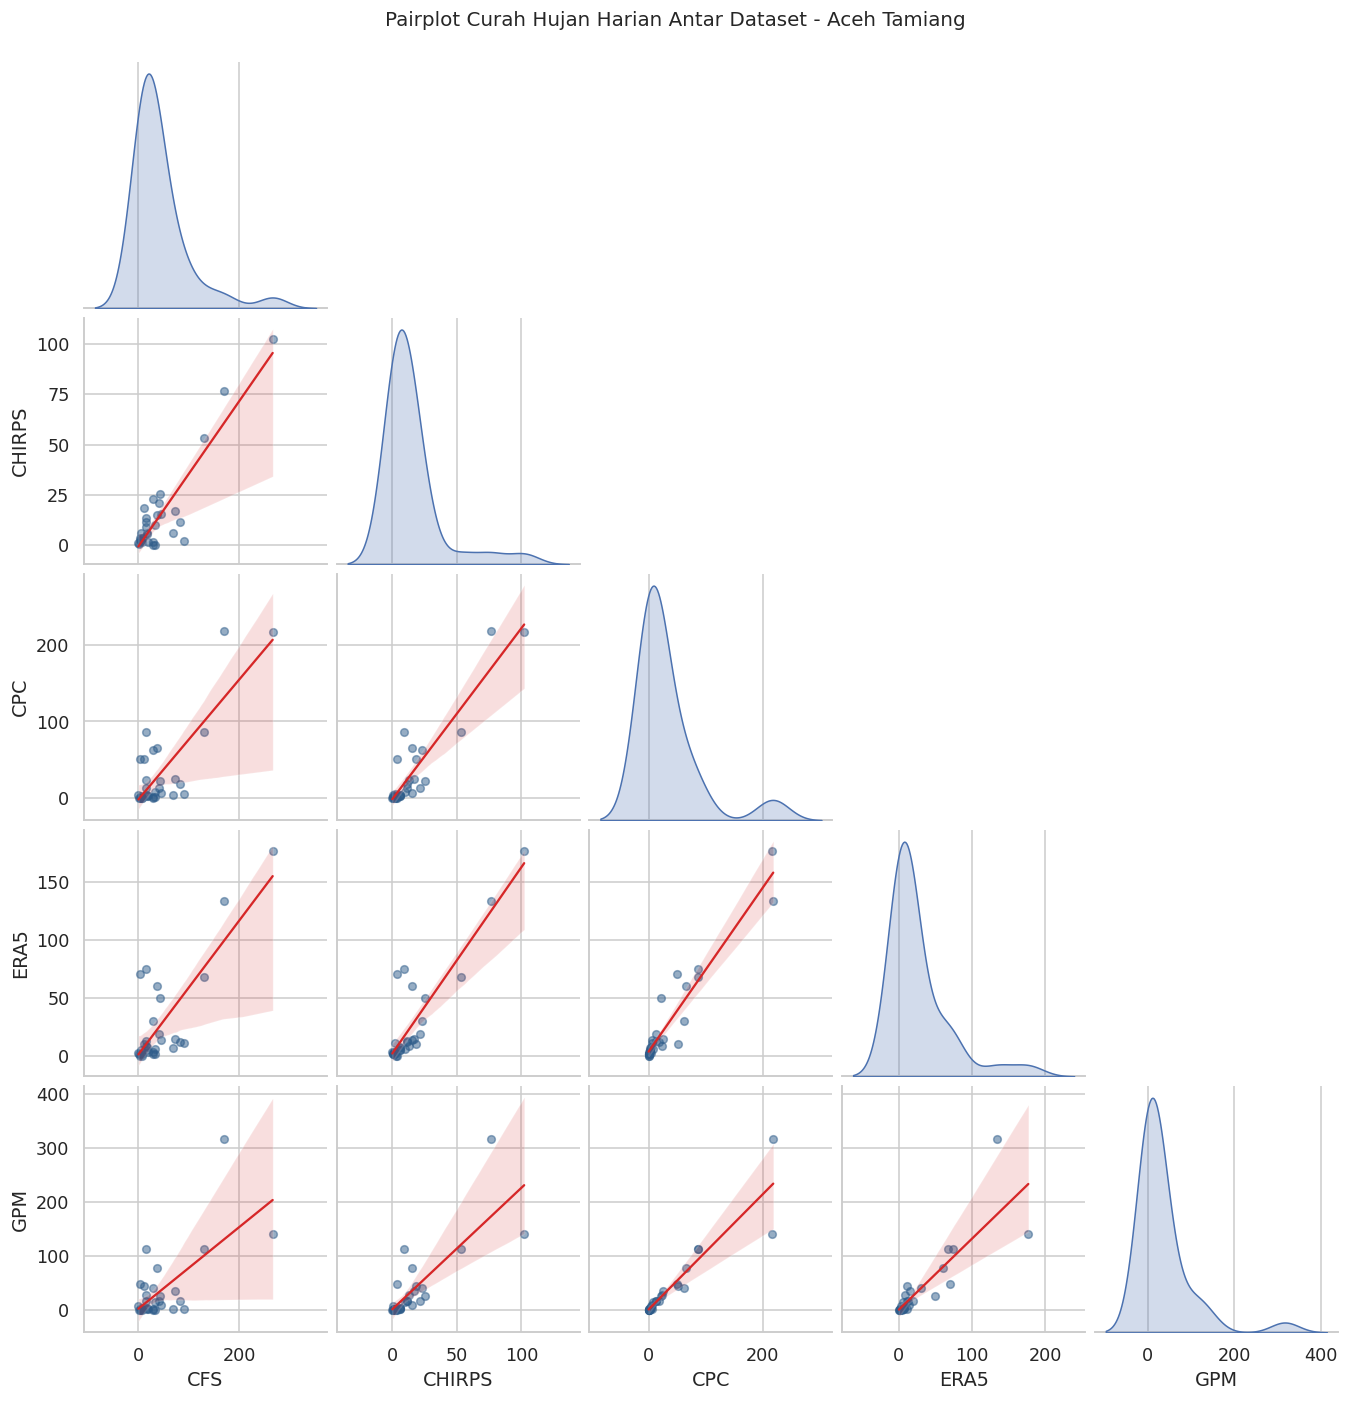

In [ ]:
# Pair Plot
g = sns.pairplot(
    df_clean[kolom_data],
    kind="reg",
    diag_kind="kde",
    plot_kws={"scatter_kws": {"alpha": 0.5, "s": 25, "color": "#2E5C8A"},
              "line_kws": {"color": "#D62728", "linewidth": 1.5}},
    corner=True
)
g.fig.suptitle("Pairplot Curah Hujan Harian Antar Dataset - Aceh Tamiang", y=1.02, fontsize=13)
g.savefig("pairplot_semua_dataset.png", dpi=150, bbox_inches='tight')
plt.show()


**Uji Statistik**

Studi validasi data hidroklimatologi untuk mengukur tingkat kesalahan (error) antar produk data, dengan salah satu dataset dijadikan acuan (referensi) pembanding

1. Bias mengukur rata-rata selisih (kecenderungan lebih tinggi/rendah) suatu dataset dibandingkan dataset acuan; nilai positif berarti dataset tersebut cenderung mengestimasi curah hujan lebih tinggi dari acuan.
2. RMSE (Root Mean Square Error) mengukur besar kesalahan rata-rata dengan memberi bobot lebih besar pada kesalahan yang besar (outlier), umum digunakan dalam validasi data hidrologi.
3. MAE (Mean Absolute Error) mengukur rata-rata selisih absolut, lebih mudah diinterpretasikan karena satuannya sama dengan data asli (mm).
4. Metrik-metrik ini melengkapi correlation heatmap, karena dua dataset bisa saja berkorelasi tinggi namun tetap memiliki bias sistematis (misalnya salah satu produk konsisten mencatat nilai lebih tinggi).


In [ ]:
#Uji Statistik

referensi = "CHIRPS"   # ganti sesuai dataset yang ingin dijadikan acuan/pembanding

hasil_evaluasi = []
for k in kolom_data:
    if k == referensi:
        continue
    obs = df_clean[referensi]
    pred = df_clean[k]

    bias = (pred - obs).mean()
    rmse = np.sqrt(((pred - obs) ** 2).mean())
    mae = (pred - obs).abs().mean()
    r, _ = stats.pearsonr(obs, pred)

    hasil_evaluasi.append({
        "Dataset": k,
        "Bias (mm)": round(bias, 2),
        "RMSE (mm)": round(rmse, 2),
        "MAE (mm)": round(mae, 2),
        "Korelasi (r)": round(r, 3)
    })

pd.DataFrame(hasil_evaluasi)

,Dataset,Bias (mm),RMSE (mm),MAE (mm),Korelasi (r)
0,CFS,28.58,46.92,29.09,0.90
1,CPC,16.93,39.43,19.94,0.92
2,ERA5,11.51,26.01,13.28,0.89
3,GPM,19.72,51.09,21.98,0.80
